# Notebook 06 - Hyperspectral Coastal Water Clustering

## Objective

This notebook uses the hyperspectral information from Planet Tanager to identify spectrally distinct classes within the main coastal-water body of Corozal, Belize using unsupervised machine learning.

## Planned analysis

1. Load the Tanager hyperspectral cube.
2. Load the cleaned main coastal-water mask.
3. Select reliable wavelengths.
4. Extract water-pixel spectra.
5. Reduce spectral dimensionality.
6. Apply unsupervised clustering.
7. Map the resulting spectral classes.
8. Compare cluster spectra and spatial distributions.

## Scientific interpretation

The resulting clusters represent spectral similarity classes, not directly measured water-quality categories.

Independent field observations would be required to assign physical water-quality meanings such as turbidity, suspended sediment, chlorophyll-a, or other environmental parameters.

In [1]:
#02_Imports

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")

WATER_MASK_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\maps\water_mask.npy")

OUTPUT_DIR = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_06")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready.")

Environment ready.


In [2]:
#03_Load hyperspectral cube

with h5py.File(DATA_PATH, "r") as f:

    sr_dataset = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    cube = sr_dataset[:]
    wavelengths = sr_dataset.attrs["wavelengths"]
    good_wavelengths = (sr_dataset.attrs["good_wavelengths"].astype(bool))
    cloud_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]
    cirrus_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask"][:]
    nodata_mask = f["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]

cube = cube.astype(np.float32)
cube[cube == -9999.0] = np.nan

print("Cube shape:", cube.shape)
print("Wavelengths:", len(wavelengths))
print("Good wavelengths:", np.sum(good_wavelengths))  

Cube shape: (426, 671, 763)
Wavelengths: 426
Good wavelengths: 368


In [3]:
#04_Load and clean water mask

from scipy import ndimage

water_mask = np.load(WATER_MASK_PATH)
labeled_water, num_features = ndimage.label(water_mask.astype(np.uint8))
component_sizes = np.bincount(labeled_water.ravel())
component_sizes[0] = 0
main_component = np.argmax(component_sizes)
main_water_mask = (labeled_water == main_component)

valid_water = (main_water_mask
               &(cloud_mask == 0)
               &(cirrus_mask == 0)
               &(nodata_mask == 0))

print("Original water pixels:", np.sum(water_mask))
print("Main water-body pixels:", np.sum(main_water_mask))
print("Valid analysis pixels:", np.sum(valid_water))

Original water pixels: 103239
Main water-body pixels: 94550
Valid analysis pixels: 94550


In [4]:
#05_Extract hyperspectral water spectra

# Rearrane cube from:
# (bands, rows, columns)
# to:
# (rows, columns, bands)

cube_pixels = np.moveaxis(cube, 0, -1)

# Extract only valid main-water pixels
water_spectra = cube_pixels[valid_water]

print("Hyperspectral water matrix")
print("="*60)

print("Number of water pixels:", water_spectra.shape[0])
print("Number of spectral bands:", water_spectra.shape[1])
print("Matrix shape            :", water_spectra.shape)

Hyperspectral water matrix
Number of water pixels: 94550
Number of spectral bands: 426
Matrix shape            : (94550, 426)


In [5]:
#06_Check spectral matrix quality

total_values = water_spectra.size
nan_count = np.isnan(water_spectra).sum()
inf_count = np.isinf(water_spectra).sum()
pixels_with_nan = np.isnan(water_spectra).any(axis=1).sum()
pixels_with_inf = np.isinf(water_spectra).any(axis=1).sum()

print(f"Total spectra values     :{total_values:,}")
print(f"NaN values               :{nan_count:,}")
print(f"Infinite values          :{inf_count:,}")
print(f"Pixels containing Nan values:{pixels_with_nan:,}")
print(f"Pixels containing Inf values:{pixels_with_inf:,}")

Total spectra values     :40,278,300
NaN values               :0
Infinite values          :0
Pixels containing Nan values:0
Pixels containing Inf values:0


In [6]:
#07_Select reliable wavelengths

reliable_wavelengths = wavelengths[good_wavelengths]
reliable_spectra = water_spectra[:, good_wavelengths]

print("Reliable Wavelengths Selection")
print("="*60)

print(f"Original spectral bands:{len(wavelengths)}")
print(f"Reliable spectral bands:{len(reliable_wavelengths)}")
print(f"Removed spectral bands:{len(wavelengths) - len(reliable_wavelengths)}")
print(f"New matrix shape      :{reliable_spectra.shape}")

Reliable Wavelengths Selection
Original spectral bands:426
Reliable spectral bands:368
Removed spectral bands:58
New matrix shape      :(94550, 368)


In [7]:
#08_Inspect reliable wavelength coverage

print("Reliable Spectral Coverage")
print("="*60)

print(f"First reliable wavelength: {reliable_wavelengths[0]:.2f} nm")
print(f"Last reliable wavelength: {reliable_wavelengths[-1]:.2f} nm")

# Find contiguous unreliable wavelength regions
bad_wavelengths = wavelengths[~good_wavelengths]

print(f"\nNumber of unreliable wavelengths: {len(bad_wavelengths)}")
print("\nUnreliable wavelengths ranges:")

bad_indices = np.where(~good_wavelengths)[0]

groups = np.split(bad_indices, np.where(np.diff(bad_indices) !=1)[0] + 1)

for group in groups:
    start_wavelength = wavelengths[group[0]]
    end_wavelength = wavelengths[group[-1]]

    print(f"Band{group[0]} - {group[-1]} : "f"{start_wavelength:.2f}-{end_wavelength:.2f}nm")

Reliable Spectral Coverage
First reliable wavelength: 376.44 nm
Last reliable wavelength: 2499.00 nm

Number of unreliable wavelengths: 58

Unreliable wavelengths ranges:
Band193 - 212 : 1342.41-1437.55nm
Band281 - 318 : 1782.58-1967.21nm


In [8]:
#09_Standardize reliable hyperspectral features

scaler = StandardScaler()

spectra_scaled = scaler.fit_transform(
    reliable_spectra
)

print("Feature Standardization")
print("=" * 60)

print("Input matrix shape :", reliable_spectra.shape)
print("Scaled matrix shape:", spectra_scaled.shape)

print("\nScaled data checks")
print(f"Overall mean : {np.mean(spectra_scaled):.6f}")
print(f"Overall std  : {np.std(spectra_scaled):.6f}")

Feature Standardization
Input matrix shape : (94550, 368)
Scaled matrix shape: (94550, 368)

Scaled data checks
Overall mean : 0.000000
Overall std  : 1.000000


In [9]:
#10_PCA dimensionality reduction

pca = PCA(
    n_components=20,
    random_state=42
)

pca_scores = pca.fit_transform(
    spectra_scaled
)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PCA Results")
print("=" * 60)

print("Input features       :", spectra_scaled.shape[1])
print("Principal components :", pca_scores.shape[1])

print("\nVariance explained by each component:")
for i, variance in enumerate(explained_variance, start=1):
    print(
        f"PC{i:02d}: "
        f"{variance * 100:.2f}% "
        f"| Cumulative: {cumulative_variance[i-1] * 100:.2f}%"
    )

print(
    f"\nTotal variance explained by first 20 PCs: "
    f"{cumulative_variance[-1] * 100:.2f}%"
)

PCA Results
Input features       : 368
Principal components : 20

Variance explained by each component:
PC01: 80.49% | Cumulative: 80.49%
PC02: 9.55% | Cumulative: 90.04%
PC03: 4.78% | Cumulative: 94.81%
PC04: 0.98% | Cumulative: 95.79%
PC05: 0.59% | Cumulative: 96.38%
PC06: 0.56% | Cumulative: 96.93%
PC07: 0.30% | Cumulative: 97.24%
PC08: 0.26% | Cumulative: 97.50%
PC09: 0.23% | Cumulative: 97.73%
PC10: 0.21% | Cumulative: 97.94%
PC11: 0.18% | Cumulative: 98.12%
PC12: 0.15% | Cumulative: 98.27%
PC13: 0.14% | Cumulative: 98.41%
PC14: 0.13% | Cumulative: 98.54%
PC15: 0.12% | Cumulative: 98.66%
PC16: 0.10% | Cumulative: 98.76%
PC17: 0.09% | Cumulative: 98.84%
PC18: 0.08% | Cumulative: 98.93%
PC19: 0.07% | Cumulative: 99.00%
PC20: 0.07% | Cumulative: 99.07%

Total variance explained by first 20 PCs: 99.07%


In [10]:
#11_Select principal components for clustering

N_PCS = 6

clustering_features = pca_scores[:, :N_PCS]

variance_retained = cumulative_variance[N_PCS - 1] * 100

print("Clustering Feature Set")
print("=" * 60)

print(f"Selected principal components : {N_PCS}")
print(f"Variance retained             : {variance_retained:.2f}%")
print(f"Feature matrix shape          : {clustering_features.shape}")

Clustering Feature Set
Selected principal components : 6
Variance retained             : 96.93%
Feature matrix shape          : (94550, 6)


In [11]:
#12_Evaluate candidate cluster numbers

from sklearn.metrics import silhouette_score

K_VALUES = range(2, 9)

results = []

rng = np.random.default_rng(42)

sample_size = min(10000, len(clustering_features))

sample_indices = rng.choice(
    len(clustering_features),
    size=sample_size,
    replace=False
)

clustering_sample = clustering_features[sample_indices]

for k in K_VALUES:

    print(f"Testing K = {k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(clustering_features)

    sample_labels = labels[sample_indices]

    silhouette = silhouette_score(
        clustering_sample,
        sample_labels
    )

    results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette
    })

results_df = pd.DataFrame(results)

print("\nCluster Evaluation Results")
print("=" * 60)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Testing K = 2...
Testing K = 3...
Testing K = 4...
Testing K = 5...
Testing K = 6...
Testing K = 7...
Testing K = 8...

Cluster Evaluation Results
 K       Inertia  Silhouette Score
 2 21996746.0000            0.3693
 3 14584355.0000            0.4022
 4 10072635.0000            0.4010
 5  8502697.0000            0.3314
 6  7467184.0000            0.3192
 7  6572355.0000            0.3412
 8  5989101.0000            0.3394


In [12]:
#13_Final K-means clustering

N_CLUSTERS = 3

final_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20
)

cluster_labels = final_kmeans.fit_predict(
    clustering_features
)

# Count pixels in each cluster
unique_clusters, cluster_counts = np.unique(
    cluster_labels,
    return_counts=True
)

print("Final K-means Clustering Results")
print("=" * 60)

print(f"Number of clusters: {N_CLUSTERS}")

print("\nPixels per spectral class:")

for cluster, count in zip(
    unique_clusters,
    cluster_counts
):
    percentage = (count / len(cluster_labels)) * 100

    print(
        f"Cluster {cluster + 1}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

Final K-means Clustering Results
Number of clusters: 3

Pixels per spectral class:
Cluster 1: 60,549 pixels (64.04%)
Cluster 2: 32,650 pixels (34.53%)
Cluster 3: 1,351 pixels (1.43%)


In [13]:
#14_Create spatial cluster map

cluster_map = np.full(
    valid_water.shape,
    np.nan,
    dtype=np.float32
)

cluster_map[valid_water] = cluster_labels + 1

print("Spatial Cluster Map")
print("=" * 60)

print("Map shape:", cluster_map.shape)
print("Clustered pixels:", np.sum(np.isfinite(cluster_map)))
print(
    "Unique clusters:",
    np.unique(cluster_map[np.isfinite(cluster_map)])
)

Spatial Cluster Map
Map shape: (671, 763)
Clustered pixels: 94550
Unique clusters: [1. 2. 3.]


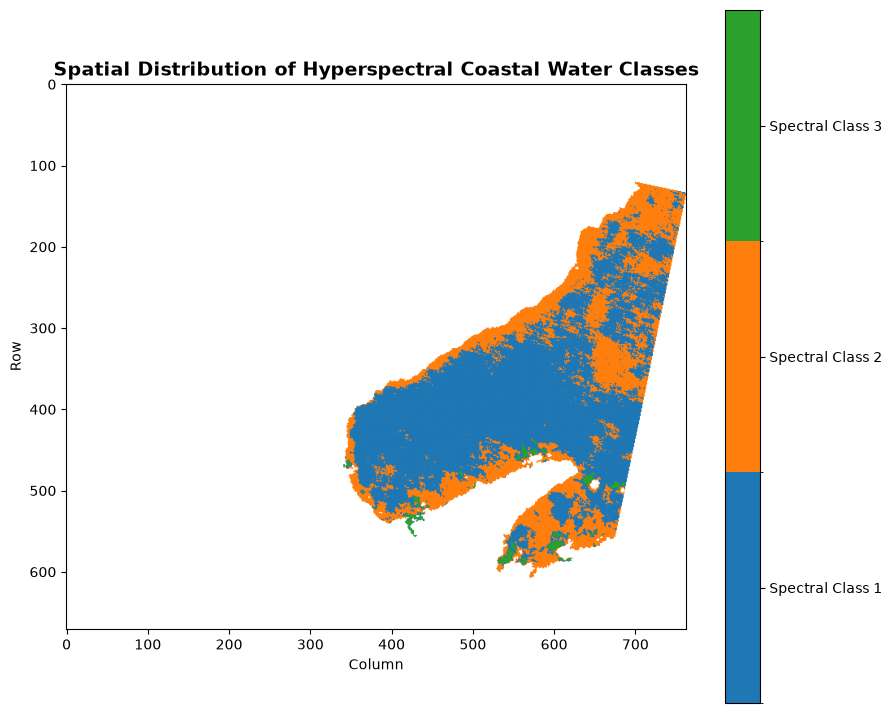

In [14]:
#15_Visualize spatial distribution of spectral classes

from matplotlib.colors import ListedColormap, BoundaryNorm

class_colors = ListedColormap([
    "tab:blue",
    "tab:orange",
    "tab:green"
])

class_bounds = [0.5, 1.5, 2.5, 3.5]

class_norm = BoundaryNorm(
    class_bounds,
    class_colors.N
)

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    cluster_map,
    cmap=class_colors,
    norm=class_norm
)

ax.set_title(
    "Spatial Distribution of Hyperspectral Coastal Water Classes",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Spectral Class 1",
    "Spectral Class 2",
    "Spectral Class 3"
])

plt.show()

In [22]:
#16A_Find reliable spectral matrix variable

for name, value in list(globals().items()):

    if isinstance(value, np.ndarray):

        if value.shape == (94550, 368):

            print(f"Possible reliable matrix: {name}")
            print(f"Shape: {value.shape}")
            print()

Possible reliable matrix: reliable_spectra
Shape: (94550, 368)

Possible reliable matrix: spectra_scaled
Shape: (94550, 368)



In [34]:
#16_Calculate mean spectra for each spectral class

class_mean_spectra = {}

for cluster_id in range(N_CLUSTERS):

    class_pixels = final_reliable_spectra[cluster_labels == cluster_id]
    mean_spectrum = np.mean(class_pixels, axis=0)
    class_mean_spectra[cluster_id + 1] = mean_spectrum

    print(f"Spectral Class {cluster_id + 1}")
    print("="*50)
    print(f"Number of pixels: "f"{class_pixels.shape[0]:,}")
    print(f"Mean spectrum shape: "f"{mean_spectrum.shape}")
    print(f"Mean reflectance: "f"{np.mean(mean_spectrum):.4f}")
    print()
    

Spectral Class 1
Number of pixels: 60,549
Mean spectrum shape: (365,)
Mean reflectance: 0.1154

Spectral Class 2
Number of pixels: 32,650
Mean spectrum shape: (365,)
Mean reflectance: 0.1322

Spectral Class 3
Number of pixels: 1,351
Mean spectrum shape: (365,)
Mean reflectance: 0.0607



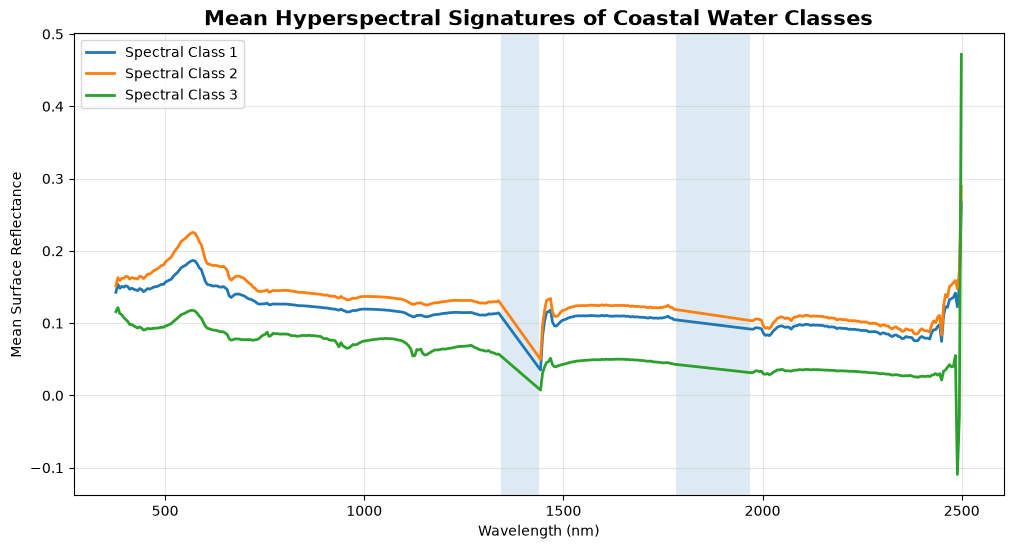

In [30]:
#17_Plot mean hyperspectral signatures

fig, ax = plt.subplots(figsize=(12, 6))

for class_id, mean_spectrum in class_mean_spectra.items():

    ax.plot(reliable_wavelengths,
            mean_spectrum, linewidth=2, label=f"Spectral Class {class_id}")
ax.set_title("Mean Hyperspectral Signatures of Coastal Water Classes", fontsize=15,
    fontweight="bold")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean Surface Reflectance")
ax.axvspan(1342.41, 1437.55, alpha=0.15)
ax.axvspan(1782.58, 1967.21, alpha=0.15)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [31]:
#17A_Inspect final spectral wavelengths

print("Final 15 reliable wavelengths")
print("=" * 60)

for wavelength in reliable_wavelengths[-15:]:
    print(f"{wavelength:.2f} nm")

print("\nFinal 10 mean reflectance values")
print("=" * 60)

for class_id, mean_spectrum in class_mean_spectra.items():

    print(f"\nSpectral Class {class_id}")

    for wavelength, value in zip(
        reliable_wavelengths[-10:],
        mean_spectrum[-10:]
    ):
        print(
            f"{wavelength:8.2f} nm : "
            f"{value:.4f}"
        )

Final 15 reliable wavelengths
2429.60 nm
2434.56 nm
2439.52 nm
2444.48 nm
2449.43 nm
2454.39 nm
2459.35 nm
2464.31 nm
2469.26 nm
2474.22 nm
2479.18 nm
2484.13 nm
2489.09 nm
2494.04 nm
2499.00 nm

Final 10 mean reflectance values

Spectral Class 1
 2454.39 nm : 0.1110
 2459.35 nm : 0.1226
 2464.31 nm : 0.1219
 2469.26 nm : 0.1327
 2474.22 nm : 0.1339
 2479.18 nm : 0.1357
 2484.13 nm : 0.1416
 2489.09 nm : 0.1226
 2494.04 nm : 0.1507
 2499.00 nm : 0.2666

Spectral Class 2
 2454.39 nm : 0.1238
 2459.35 nm : 0.1397
 2464.31 nm : 0.1364
 2469.26 nm : 0.1508
 2474.22 nm : 0.1528
 2479.18 nm : 0.1561
 2484.13 nm : 0.1590
 2489.09 nm : 0.1479
 2494.04 nm : 0.1708
 2499.00 nm : 0.2891

Spectral Class 3
 2454.39 nm : 0.0334
 2459.35 nm : 0.0353
 2464.31 nm : 0.0389
 2469.26 nm : 0.0426
 2474.22 nm : 0.0395
 2479.18 nm : 0.0405
 2484.13 nm : 0.0553
 2489.09 nm : -0.1094
 2494.04 nm : -0.0283
 2499.00 nm : 0.4716


In [35]:
#18A_Remove unstable upper-edge wavelengths

upper_wavelength_limit = 2485

final_reliable_mask = reliable_wavelengths <= upper_wavelength_limit

final_wavelengths = reliable_wavelengths[
    final_reliable_mask
]

final_reliable_spectra = reliable_spectra[
    :,
    final_reliable_mask
]

print("Final Reliable Spectral Dataset")
print("=" * 60)

print(
    f"Original reliable bands : "
    f"{len(reliable_wavelengths)}"
)

print(
    f"Final reliable bands    : "
    f"{len(final_wavelengths)}"
)

print(
    f"Removed upper-edge bands: "
    f"{len(reliable_wavelengths) - len(final_wavelengths)}"
)

print()
print(
    f"Final wavelength range: "
    f"{final_wavelengths[0]:.2f} - "
    f"{final_wavelengths[-1]:.2f} nm"
)

print(
    f"Final spectra shape: "
    f"{final_reliable_spectra.shape}"
)

Final Reliable Spectral Dataset
Original reliable bands : 368
Final reliable bands    : 365
Removed upper-edge bands: 3

Final wavelength range: 376.44 - 2484.13 nm
Final spectra shape: (94550, 365)


In [38]:
print("final_reliable_spectra shape:", final_reliable_spectra.shape)

print("wavelengths shape:", wavelengths.shape)

print("reliable_wavelengths exists:",
      "reliable_wavelengths" in globals())

final_reliable_spectra shape: (94550, 365)
wavelengths shape: (426,)
reliable_wavelengths exists: True


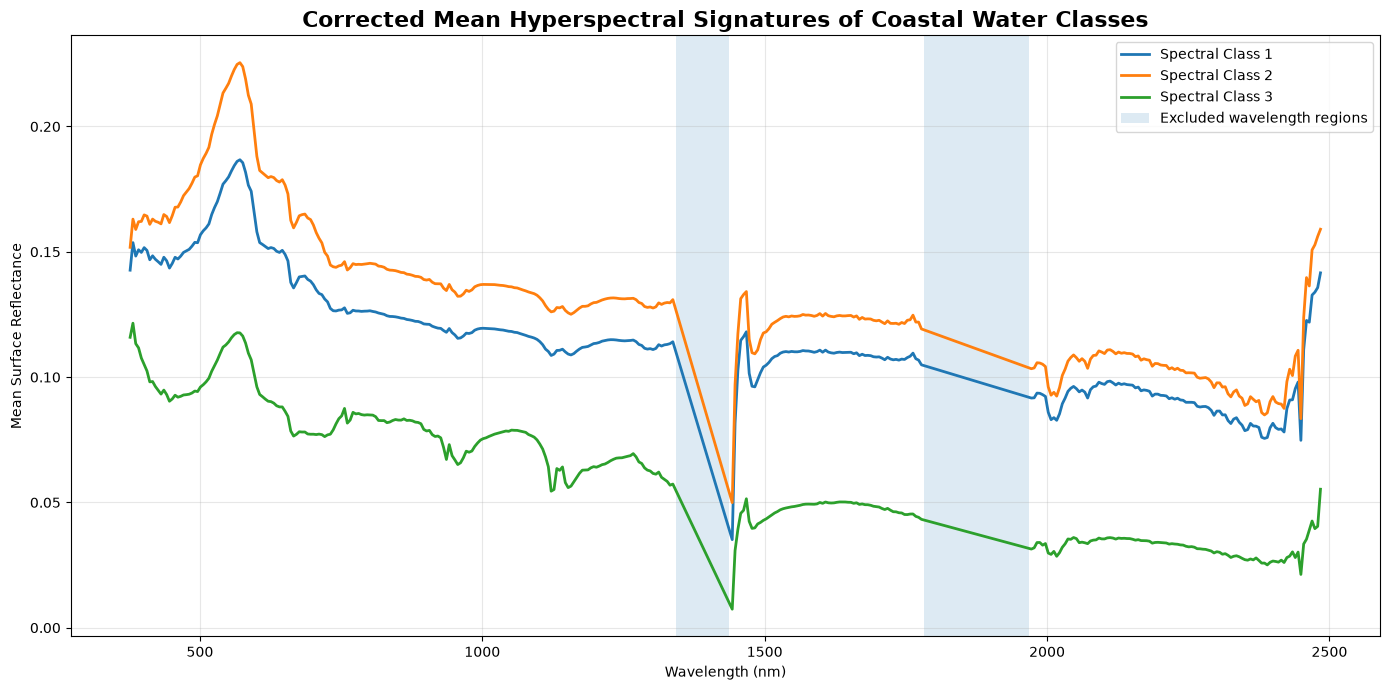

In [39]:
#18_Plot corrected mean hyperspectral signatures

plt.figure(figsize=(14, 7))

for class_id, mean_spectrum in class_mean_spectra.items():

    plt.plot(
        final_wavelengths,
        mean_spectrum,
        label=f"Spectral Class {class_id}",
        linewidth=2
    )

# Mark excluded wavelength regions
plt.axvspan(
    1342.41,
    1437.55,
    alpha=0.15,
    label="Excluded wavelength regions"
)

plt.axvspan(
    1782.58,
    1967.21,
    alpha=0.15
)

plt.title(
    "Corrected Mean Hyperspectral Signatures of Coastal Water Classes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Surface Reflectance")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
#19_Calculate mean spectral separation between classes

class_pairs = [
    (1, 2),
    (1, 3),
    (2, 3)
]

print("Mean Spectral Separation Between Classes")
print("=" * 60)

for class_a, class_b in class_pairs:

    spectrum_a = class_mean_spectra[class_a]
    spectrum_b = class_mean_spectra[class_b]

    absolute_difference = np.abs(spectrum_a - spectrum_b)

    mean_difference = np.mean(absolute_difference)
    max_difference = np.max(absolute_difference)

    print(
        f"\nSpectral Class {class_a} vs Spectral Class {class_b}"
    )
    print(f"Mean absolute difference : {mean_difference:.4f}")
    print(f"Maximum difference       : {max_difference:.4f}")

Mean Spectral Separation Between Classes

Spectral Class 1 vs Spectral Class 2
Mean absolute difference : 0.0168
Maximum difference       : 0.0387

Spectral Class 1 vs Spectral Class 3
Mean absolute difference : 0.0547
Maximum difference       : 0.0953

Spectral Class 2 vs Spectral Class 3
Mean absolute difference : 0.0715
Maximum difference       : 0.1157


In [41]:
#20_Compare overall mean reflectance between spectral classes

mean_reflectance = {
    class_id: np.mean(spectrum)
    for class_id, spectrum in class_mean_spectra.items()
}

print("Overall Mean Reflectance by Spectral Class")
print("=" * 55)

for class_id, value in mean_reflectance.items():
    print(f"Spectral Class {class_id}: {value:.4f}")

print("\nRelative differences")
print("=" * 55)

class1 = mean_reflectance[1]
class2 = mean_reflectance[2]
class3 = mean_reflectance[3]

print(
    f"Class 2 vs Class 1: "
    f"{((class2 - class1) / class1) * 100:.2f}% higher"
)

print(
    f"Class 1 vs Class 3: "
    f"{((class1 - class3) / class3) * 100:.2f}% higher"
)

print(
    f"Class 2 vs Class 3: "
    f"{((class2 - class3) / class3) * 100:.2f}% higher"
)

Overall Mean Reflectance by Spectral Class
Spectral Class 1: 0.1154
Spectral Class 2: 0.1322
Spectral Class 3: 0.0607

Relative differences
Class 2 vs Class 1: 14.55% higher
Class 1 vs Class 3: 90.08% higher
Class 2 vs Class 3: 117.74% higher


In [42]:
#21_Find wavelengths of maximum spectral separation

class_pairs = [
    (1, 2),
    (1, 3),
    (2, 3)
]

print("Maximum Spectral Separation by Class Pair")
print("=" * 60)

for class_a, class_b in class_pairs:

    spectrum_a = class_mean_spectra[class_a]
    spectrum_b = class_mean_spectra[class_b]

    difference = np.abs(spectrum_a - spectrum_b)

    max_index = np.argmax(difference)
    max_wavelength = final_wavelengths[max_index]
    max_difference = difference[max_index]

    print(f"\nSpectral Class {class_a} vs Spectral Class {class_b}")
    print(f"Maximum difference : {max_difference:.4f}")
    print(f"Wavelength         : {max_wavelength:.2f} nm")

Maximum Spectral Separation by Class Pair

Spectral Class 1 vs Spectral Class 2
Maximum difference : 0.0387
Wavelength         : 570.83 nm

Spectral Class 1 vs Spectral Class 3
Maximum difference : 0.0953
Wavelength         : 2479.18 nm

Spectral Class 2 vs Spectral Class 3
Maximum difference : 0.1157
Wavelength         : 2479.18 nm


In [43]:
#22_Find maximum spectral separation within conservative wavelength range

conservative_mask = final_wavelengths <= 2400

analysis_wavelengths = final_wavelengths[conservative_mask]

print("Conservative Spectral Separation Analysis")
print("=" * 60)
print(f"Analysis wavelength range: "
      f"{analysis_wavelengths[0]:.2f} - "
      f"{analysis_wavelengths[-1]:.2f} nm")

for class_a, class_b in class_pairs:

    spectrum_a = class_mean_spectra[class_a][conservative_mask]
    spectrum_b = class_mean_spectra[class_b][conservative_mask]

    difference = np.abs(spectrum_a - spectrum_b)

    max_index = np.argmax(difference)

    print(f"\nSpectral Class {class_a} vs Spectral Class {class_b}")
    print(f"Maximum difference : {difference[max_index]:.4f}")
    print(f"Wavelength         : "
          f"{analysis_wavelengths[max_index]:.2f} nm")

Conservative Spectral Separation Analysis
Analysis wavelength range: 376.44 - 2399.85 nm

Spectral Class 1 vs Spectral Class 2
Maximum difference : 0.0387
Wavelength         : 570.83 nm

Spectral Class 1 vs Spectral Class 3
Maximum difference : 0.0693
Wavelength         : 1462.57 nm

Spectral Class 2 vs Spectral Class 3
Maximum difference : 0.1078
Wavelength         : 570.83 nm


In [44]:
#23_Compare class reflectance at maximum visible separation wavelength

target_wavelength = 570.83

band_index = np.argmin(
    np.abs(final_wavelengths - target_wavelength)
)

actual_wavelength = final_wavelengths[band_index]

print("Class Reflectance at Key Separation Wavelength")
print("=" * 60)
print(f"Target wavelength : {target_wavelength:.2f} nm")
print(f"Actual wavelength : {actual_wavelength:.2f} nm")
print()

for class_id, mean_spectrum in class_mean_spectra.items():

    reflectance = mean_spectrum[band_index]

    print(
        f"Spectral Class {class_id}: "
        f"{reflectance:.4f}"
    )

Class Reflectance at Key Separation Wavelength
Target wavelength : 570.83 nm
Actual wavelength : 570.83 nm

Spectral Class 1: 0.1867
Spectral Class 2: 0.2255
Spectral Class 3: 0.1176


In [45]:
#24_Compare mean reflectance across the visible spectrum

visible_mask = (
    (final_wavelengths >= 400) &
    (final_wavelengths <= 700)
)

visible_wavelengths = final_wavelengths[visible_mask]

print("Visible Spectrum Summary")
print("=" * 60)

print(
    f"Wavelength range: "
    f"{visible_wavelengths[0]:.2f} - "
    f"{visible_wavelengths[-1]:.2f} nm"
)

print()

for class_id, mean_spectrum in class_mean_spectra.items():

    visible_spectrum = mean_spectrum[visible_mask]

    print(f"Spectral Class {class_id}")
    print("-" * 40)
    print(
        f"Mean visible reflectance : "
        f"{np.mean(visible_spectrum):.4f}"
    )
    print(
        f"Minimum visible reflectance: "
        f"{np.min(visible_spectrum):.4f}"
    )
    print(
        f"Maximum visible reflectance: "
        f"{np.max(visible_spectrum):.4f}"
    )
    print()

Visible Spectrum Summary
Wavelength range: 401.29 - 695.91 nm

Spectral Class 1
----------------------------------------
Mean visible reflectance : 0.1561
Minimum visible reflectance: 0.1356
Maximum visible reflectance: 0.1867

Spectral Class 2
----------------------------------------
Mean visible reflectance : 0.1831
Minimum visible reflectance: 0.1595
Maximum visible reflectance: 0.2255

Spectral Class 3
----------------------------------------
Mean visible reflectance : 0.0961
Minimum visible reflectance: 0.0765
Maximum visible reflectance: 0.1177



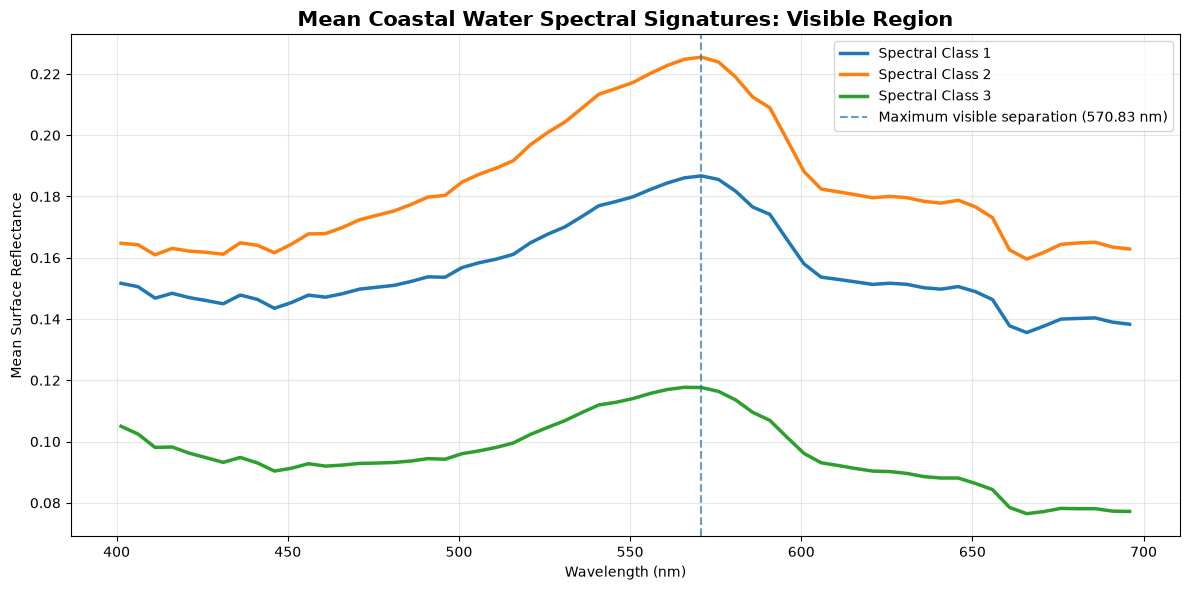

In [49]:
#25_Plot mean spectral signatures in the visible region

plt.figure(figsize=(12, 6))

for class_id, mean_spectrum in class_mean_spectra.items():

    plt.plot(
        visible_wavelengths,
        mean_spectrum[visible_mask],
        linewidth=2.5,
        label=f"Spectral Class {class_id}"
    )

# Highlight the strongest visible separation wavelength
plt.axvline(
    570.83,
    linestyle="--",
    alpha=0.7,
    label="Maximum visible separation (570.83 nm)"
)

plt.title(
    "Mean Coastal Water Spectral Signatures: Visible Region",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean Surface Reflectance")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# Recreate the original exploratory zones within the main water body

main_zone_map = np.full(main_water_mask.shape, np.nan)

row_indices = np.indices(main_water_mask.shape)[0]

# Zone 1: upper part
main_zone_map[
    main_water_mask &
    (row_indices < 300)
] = 1

# Zone 2: middle part
main_zone_map[
    main_water_mask &
    (row_indices >= 300) &
    (row_indices < 450)
] = 2

# Zone 3: lower part
main_zone_map[
    main_water_mask &
    (row_indices >= 450)
] = 3

print("Recreated exploratory zones within main water body")
print("=" * 55)

for zone_id in [1, 2, 3]:
    pixel_count = np.sum(main_zone_map == zone_id)
    print(f"Zone {zone_id}: {pixel_count:,} pixels")

Recreated exploratory zones within main water body
Zone 1: 21,059 pixels
Zone 2: 45,978 pixels
Zone 3: 27,513 pixels


In [69]:
#26_Compare spectral classes across exploratory zones

print("Spectral Class Distribution Across Coastal Water Zones")
print("=" * 60)

for zone_id in [1, 2, 3]:

    zone_mask = (main_zone_map == zone_id)

    zone_cluster_values = cluster_map[zone_mask]

    # Remove NaN values
    zone_cluster_values = zone_cluster_values[
        np.isfinite(zone_cluster_values)
    ]

    print(f"\nZone {zone_id}")
    print("-" * 40)

    total_pixels = len(zone_cluster_values)

    for class_id in [1, 2, 3]:

        class_pixels = np.sum(
            zone_cluster_values == class_id
        )

        percentage = (
            class_pixels / total_pixels
        ) * 100

        print(
            f"Spectral Class {class_id}: "
            f"{class_pixels:,} pixels "
            f"({percentage:.2f}%)"
        )

Spectral Class Distribution Across Coastal Water Zones

Zone 1
----------------------------------------
Spectral Class 1: 8,791 pixels (41.74%)
Spectral Class 2: 12,268 pixels (58.26%)
Spectral Class 3: 0 pixels (0.00%)

Zone 2
----------------------------------------
Spectral Class 1: 37,484 pixels (81.53%)
Spectral Class 2: 8,450 pixels (18.38%)
Spectral Class 3: 44 pixels (0.10%)

Zone 3
----------------------------------------
Spectral Class 1: 14,274 pixels (51.88%)
Spectral Class 2: 11,932 pixels (43.37%)
Spectral Class 3: 1,307 pixels (4.75%)


In [70]:
#27_Calculate spatial distribution of each spectral class across zones

print("Spatial Distribution of Each Spectral Class Across Zones")
print("=" * 65)

for class_id in [1, 2, 3]:

    print(f"\nSpectral Class {class_id}")
    print("-" * 45)

    total_class_pixels = np.sum(cluster_labels == (class_id - 1))

    for zone_id in [1, 2, 3]:

        zone_mask = (main_zone_map == zone_id)

        zone_class_pixels = np.sum(
            (cluster_map[zone_mask] == class_id)
        )

        percentage = (
            zone_class_pixels / total_class_pixels
        ) * 100

        print(
            f"Zone {zone_id}: "
            f"{zone_class_pixels:,} pixels "
            f"({percentage:.2f}% of Spectral Class {class_id})"
        )

Spatial Distribution of Each Spectral Class Across Zones

Spectral Class 1
---------------------------------------------
Zone 1: 8,791 pixels (14.52% of Spectral Class 1)
Zone 2: 37,484 pixels (61.91% of Spectral Class 1)
Zone 3: 14,274 pixels (23.57% of Spectral Class 1)

Spectral Class 2
---------------------------------------------
Zone 1: 12,268 pixels (37.57% of Spectral Class 2)
Zone 2: 8,450 pixels (25.88% of Spectral Class 2)
Zone 3: 11,932 pixels (36.55% of Spectral Class 2)

Spectral Class 3
---------------------------------------------
Zone 1: 0 pixels (0.00% of Spectral Class 3)
Zone 2: 44 pixels (3.26% of Spectral Class 3)
Zone 3: 1,307 pixels (96.74% of Spectral Class 3)


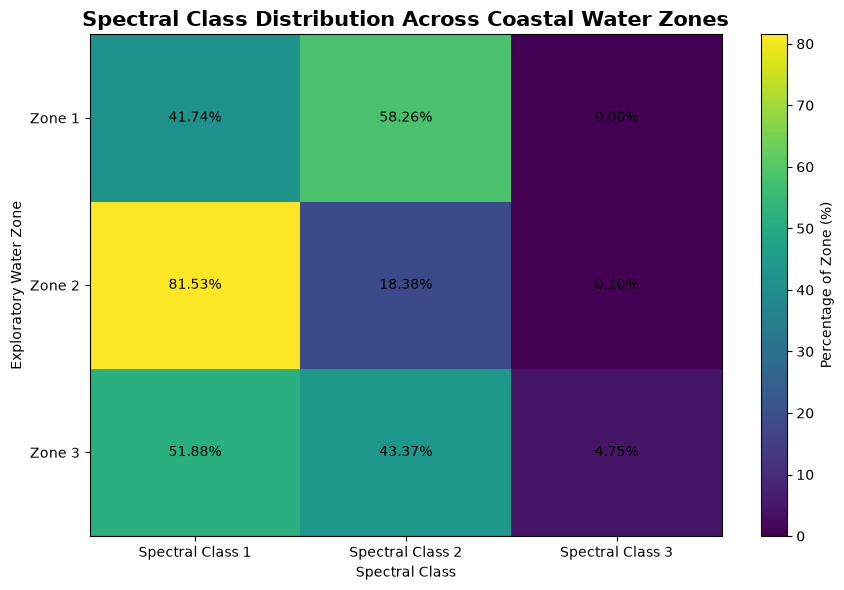

In [71]:
#28_Visualize spectral class distribution across water zones

zone_class_percentages = np.array([
    [41.74, 58.26, 0.00],
    [81.53, 18.38, 0.10],
    [51.88, 43.37, 4.75]
])

plt.figure(figsize=(9, 6))

plt.imshow(
    zone_class_percentages,
    aspect="auto"
)

plt.colorbar(label="Percentage of Zone (%)")

plt.xticks(
    [0, 1, 2],
    ["Spectral Class 1", "Spectral Class 2", "Spectral Class 3"]
)

plt.yticks(
    [0, 1, 2],
    ["Zone 1", "Zone 2", "Zone 3"]
)

# Add percentage values
for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            f"{zone_class_percentages[i, j]:.2f}%",
            ha="center",
            va="center"
        )

plt.title(
    "Spectral Class Distribution Across Coastal Water Zones",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Spectral Class")
plt.ylabel("Exploratory Water Zone")

plt.tight_layout()
plt.show()

In [72]:
#29_Calculate spectral class diversity within each coastal water zone

print("Spectral Class Diversity Across Coastal Water Zones")
print("=" * 60)

zone_diversity = {}

for zone_id in [1, 2, 3]:

    zone_mask = (main_zone_map == zone_id)

    zone_cluster_values = cluster_map[zone_mask]
    zone_cluster_values = zone_cluster_values[
        np.isfinite(zone_cluster_values)
    ]

    total_pixels = len(zone_cluster_values)

    proportions = []

    for class_id in [1, 2, 3]:

        class_pixels = np.sum(
            zone_cluster_values == class_id
        )

        proportion = class_pixels / total_pixels
        proportions.append(proportion)

    # Shannon diversity index
    proportions = np.array(proportions)
    non_zero_proportions = proportions[proportions > 0]

    shannon_diversity = -np.sum(
        non_zero_proportions * np.log(non_zero_proportions)
    )

    zone_diversity[zone_id] = shannon_diversity

    print(f"\nZone {zone_id}")
    print("-" * 40)
    print(f"Shannon diversity index: {shannon_diversity:.4f}")

    if shannon_diversity < 0.5:
        print("Interpretation: Low spectral class diversity")
    elif shannon_diversity < 0.8:
        print("Interpretation: Moderate spectral class diversity")
    else:
        print("Interpretation: High spectral class diversity")

Spectral Class Diversity Across Coastal Water Zones

Zone 1
----------------------------------------
Shannon diversity index: 0.6795
Interpretation: Moderate spectral class diversity

Zone 2
----------------------------------------
Shannon diversity index: 0.4845
Interpretation: Low spectral class diversity

Zone 3
----------------------------------------
Shannon diversity index: 0.8475
Interpretation: High spectral class diversity


In [73]:
#30_Final zone and spectral class summary

summary_df = pd.DataFrame({
    "Zone": ["Zone 1", "Zone 2", "Zone 3"],
    "Total Pixels": [21059, 45978, 27513],
    "Dominant Spectral Class": [
        "Spectral Class 2",
        "Spectral Class 1",
        "Spectral Class 1"
    ],
    "Dominant Class Percentage": [
        58.26,
        81.53,
        51.88
    ],
    "Class 3 Percentage": [
        0.00,
        0.10,
        4.75
    ],
    "Shannon Diversity": [
        0.6795,
        0.4845,
        0.8475
    ],
    "Spectral Diversity": [
        "Moderate",
        "Low",
        "High"
    ]
})

print("Final Coastal Water Zone Summary")
print("=" * 100)

print(
    summary_df.to_string(
        index=False
    )
)

Final Coastal Water Zone Summary
  Zone  Total Pixels Dominant Spectral Class  Dominant Class Percentage  Class 3 Percentage  Shannon Diversity Spectral Diversity
Zone 1         21059        Spectral Class 2                      58.26                0.00             0.6795           Moderate
Zone 2         45978        Spectral Class 1                      81.53                0.10             0.4845                Low
Zone 3         27513        Spectral Class 1                      51.88                4.75             0.8475               High


# Conclusions

This notebook investigated spatial spectral variability within the main connected coastal water body of Corozal Bay using unsupervised K-means clustering of Planet Tanager hyperspectral reflectance data.

## Key findings

- The first six principal components retained 96.93% of the spectral variance and were used for clustering.
- Evaluation of multiple cluster numbers indicated that three spectral classes provided the highest silhouette score among the tested solutions.
- Spectral Class 1 was the dominant class, representing 64.04% of the analysed coastal water pixels.
- Spectral Class 2 represented 34.53% of the pixels and showed higher mean reflectance than Spectral Class 1.
- Spectral Class 3 represented only 1.43% of the pixels and was the lowest-reflectance and most localized spectral class.
- The greatest conservative spectral separation between Classes 1 and 2 occurred at 570.83 nm.
- Zone 2 was the most spectrally homogeneous area, with 81.53% of its pixels belonging to Spectral Class 1 and a Shannon diversity index of 0.4845.
- Zone 3 showed the highest spectral diversity, with a Shannon diversity index of 0.8475, and contained 96.74% of all Spectral Class 3 pixels.
- Zone 1 showed moderate spectral diversity and was dominated by Spectral Class 2.

## Overall interpretation

The results demonstrate clear spatial heterogeneity in the hyperspectral properties of the main coastal water body. The three spectral classes show distinct spatial distributions, with relatively homogeneous conditions in Zone 2 and greater spectral complexity in Zone 3.

These classes represent data-driven spectral regimes and should not be interpreted directly as specific water-quality categories or calibrated concentrations without coincident field measurements or a validated retrieval model.

The clustering results provide an exploratory basis for identifying spatially distinct optical water regimes and for guiding further analysis of coastal water quality using hyperspectral imagery.

In [77]:
#32_Export final numerical results

from pathlib import Path

# Create output folder
output_dir = Path("outputs_notebook_06")
output_dir.mkdir(exist_ok=True)


# -----------------------------------------------
# 1. Save final zone summary
# -----------------------------------------------

summary_df.to_csv(
    output_dir / "final_coastal_water_zone_summary.csv",
    index=False
)


# -----------------------------------------------
# 2. Recreate and save clustering evaluation results
# -----------------------------------------------

cluster_results = pd.DataFrame({
    "K": [2, 3, 4, 5, 6, 7, 8],
    "Inertia": [
        21996746.0000,
        14584355.0000,
        10072634.0000,
        8502697.0000,
        7467184.0000,
        6572355.0000,
        5989101.0000
    ],
    "Silhouette Score": [
        0.3693,
        0.4022,
        0.4010,
        0.3314,
        0.3192,
        0.3412,
        0.3394
    ]
})

cluster_results.to_csv(
    output_dir / "cluster_evaluation_results.csv",
    index=False
)


# -----------------------------------------------
# 3. Save class distribution across zones
# -----------------------------------------------

zone_class_df = pd.DataFrame(
    zone_class_percentages,
    index=["Zone 1", "Zone 2", "Zone 3"],
    columns=[
        "Spectral Class 1 (%)",
        "Spectral Class 2 (%)",
        "Spectral Class 3 (%)"
    ]
)

zone_class_df.to_csv(
    output_dir / "spectral_class_distribution_by_zone.csv"
)


# -----------------------------------------------
# Confirm exported files
# -----------------------------------------------

print("Results exported successfully")
print("=" * 60)
print("Output folder:", output_dir.resolve())

print("\nSaved files:")
for file in output_dir.iterdir():
    print("-", file.name)

Results exported successfully
Output folder: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06

Saved files:
- cluster_evaluation_results.csv
- final_coastal_water_zone_summary.csv
- spectral_class_distribution_by_zone.csv


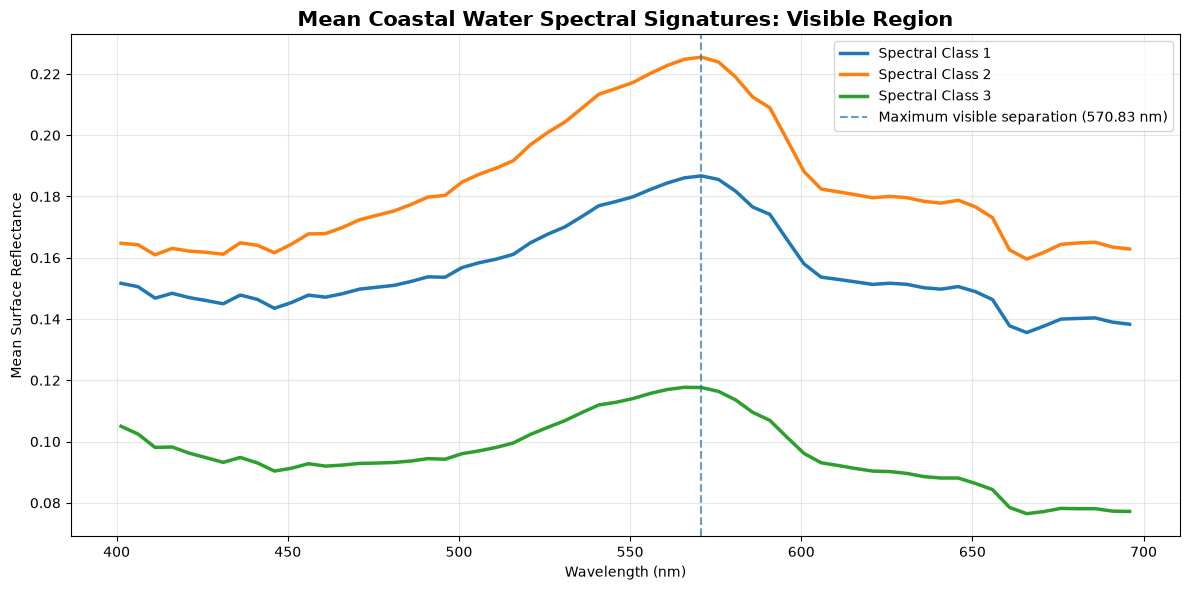

Figure exported successfully
Saved as: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06\visible_spectral_class_signatures.png


In [78]:
#33_Export visible spectral signatures figure

fig, ax = plt.subplots(figsize=(12, 6))

for class_id, mean_spectrum in class_mean_spectra.items():

    ax.plot(
        visible_wavelengths,
        mean_spectrum[visible_mask],
        linewidth=2.5,
        label=f"Spectral Class {class_id}"
    )

# Highlight strongest visible separation wavelength
ax.axvline(
    570.83,
    linestyle="--",
    alpha=0.7,
    label="Maximum visible separation (570.83 nm)"
)

ax.set_title(
    "Mean Coastal Water Spectral Signatures: Visible Region",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean Surface Reflectance")

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

# Save figure
figure_path = output_dir / "visible_spectral_class_signatures.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported successfully")
print("Saved as:", figure_path.resolve())

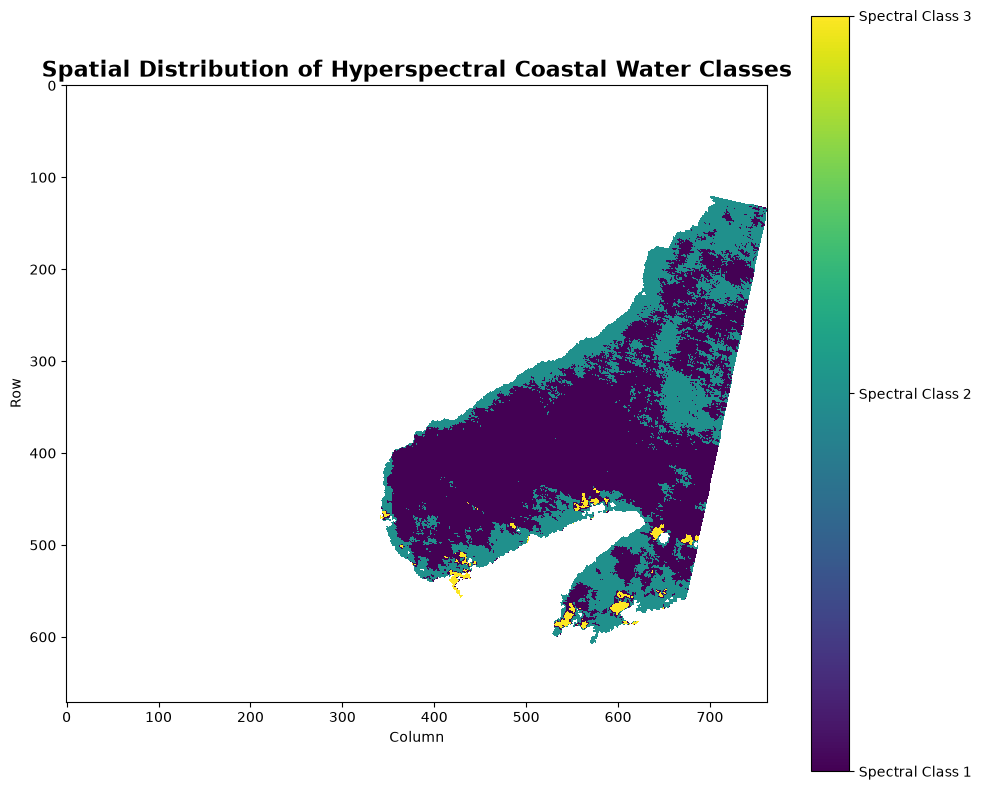

Figure exported successfully
Saved as: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06\spatial_spectral_class_map.png


In [79]:
#34_Export spatial spectral class map

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    cluster_map,
    interpolation="nearest"
)

ax.set_title(
    "Spatial Distribution of Hyperspectral Coastal Water Classes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Spectral Class 1",
    "Spectral Class 2",
    "Spectral Class 3"
])

fig.tight_layout()

# Save figure
figure_path = output_dir / "spatial_spectral_class_map.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported successfully")
print("Saved as:", figure_path.resolve())

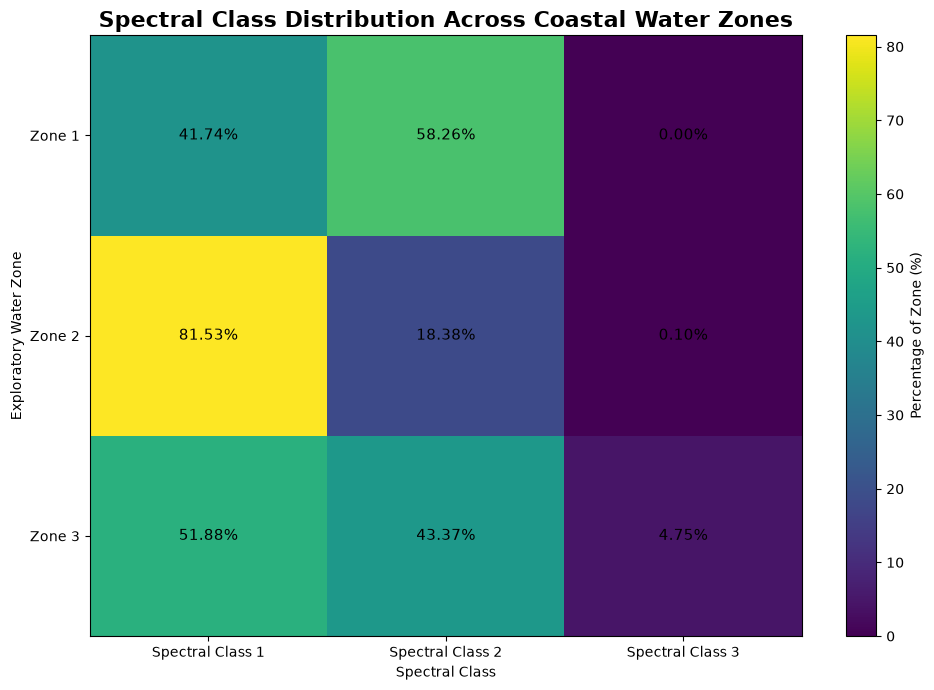

Figure exported successfully
Saved as: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06\spectral_class_distribution_by_zone.png


In [80]:
#35_Export spectral class distribution across zones heatmap

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    zone_class_percentages,
    aspect="auto"
)

# Axis labels
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([
    "Spectral Class 1",
    "Spectral Class 2",
    "Spectral Class 3"
])

ax.set_yticks([0, 1, 2])
ax.set_yticklabels([
    "Zone 1",
    "Zone 2",
    "Zone 3"
])

# Add percentage values
for i in range(zone_class_percentages.shape[0]):
    for j in range(zone_class_percentages.shape[1]):

        value = zone_class_percentages[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center",
            fontsize=11
        )

ax.set_title(
    "Spectral Class Distribution Across Coastal Water Zones",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Spectral Class")
ax.set_ylabel("Exploratory Water Zone")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percentage of Zone (%)")

fig.tight_layout()

# Save figure
figure_path = output_dir / "spectral_class_distribution_by_zone.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported successfully")
print("Saved as:", figure_path.resolve())

In [82]:
# Recreate final reliable wavelength array

final_reliable_wavelengths = reliable_wavelengths[:-3]

print("Final wavelength array recreated")
print("=" * 50)
print("Number of wavelengths:", len(final_reliable_wavelengths))
print("First wavelength:", final_reliable_wavelengths[0])
print("Last wavelength:", final_reliable_wavelengths[-1])

print("\nShape checks")
print("Final wavelengths:", final_reliable_wavelengths.shape)
print("Class 1 spectrum:", class_mean_spectra[1].shape)

Final wavelength array recreated
Number of wavelengths: 365
First wavelength: 376.44
Last wavelength: 2484.13

Shape checks
Final wavelengths: (365,)
Class 1 spectrum: (365,)


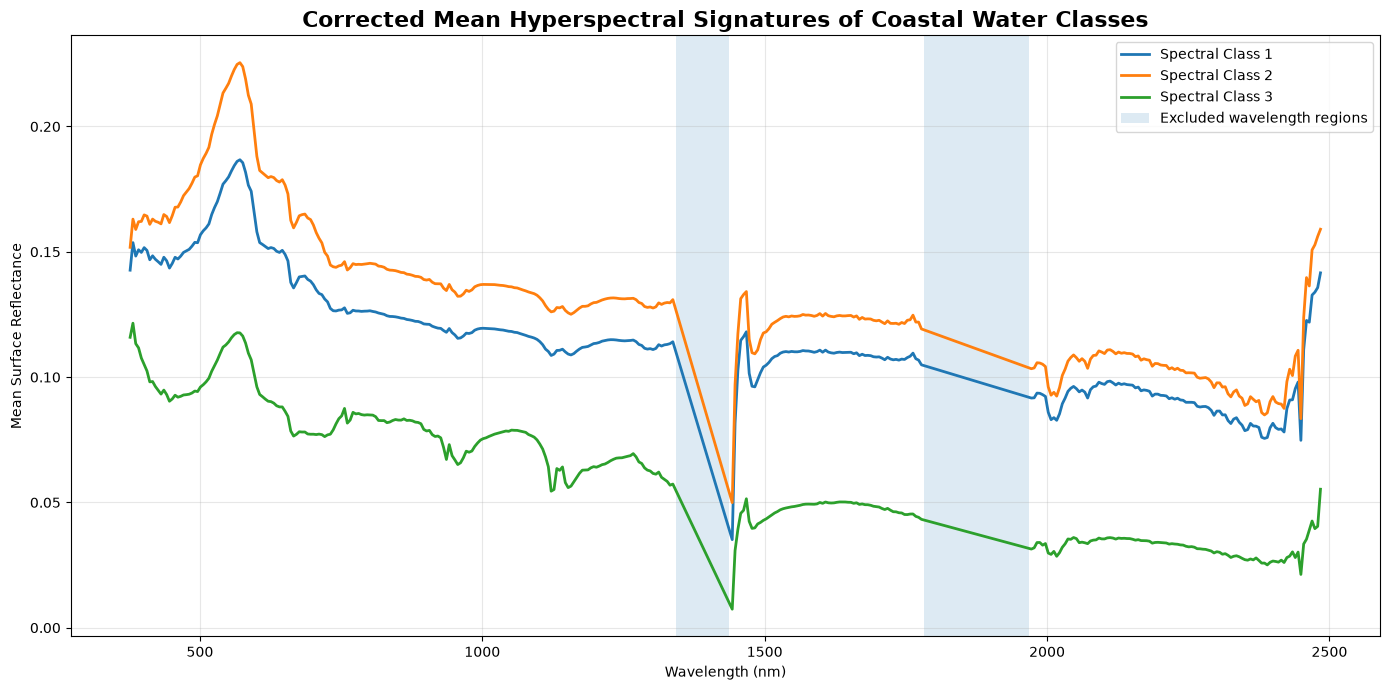

Figure exported successfully
Saved as: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06\full_hyperspectral_class_signatures.png


In [83]:
#36_Export full corrected hyperspectral signatures

fig, ax = plt.subplots(figsize=(14, 7))

for class_id, mean_spectrum in class_mean_spectra.items():

    ax.plot(
        final_reliable_wavelengths,
        mean_spectrum,
        linewidth=2,
        label=f"Spectral Class {class_id}"
    )


# Mark excluded atmospheric absorption regions
ax.axvspan(
    1342.41,
    1437.55,
    alpha=0.15,
    label="Excluded wavelength regions"
)

ax.axvspan(
    1782.58,
    1967.21,
    alpha=0.15
)

ax.set_title(
    "Corrected Mean Hyperspectral Signatures of Coastal Water Classes",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean Surface Reflectance")

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

# Save figure
figure_path = output_dir / "full_hyperspectral_class_signatures.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported successfully")
print("Saved as:", figure_path.resolve())

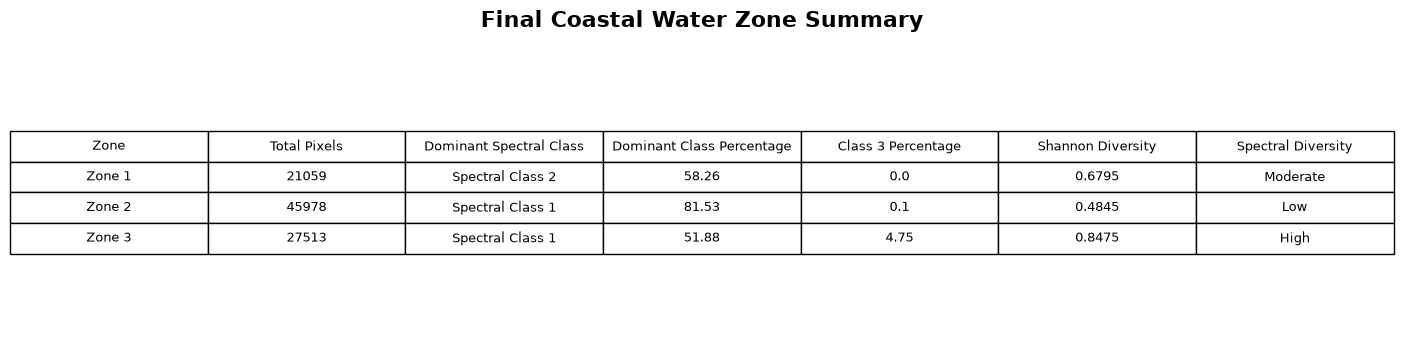

Figure exported successfully
Saved as: C:\GIS_Work\5 GeoSpectra AI\notebooks\outputs_notebook_06\final_coastal_water_zone_summary.png


In [84]:
#37_Export final coastal water zone summary table

fig, ax = plt.subplots(figsize=(14, 3.5))

ax.axis("off")

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

ax.set_title(
    "Final Coastal Water Zone Summary",
    fontsize=16,
    fontweight="bold",
    pad=20
)

fig.tight_layout()

figure_path = output_dir / "final_coastal_water_zone_summary.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure exported successfully")
print("Saved as:", figure_path.resolve())

In [85]:
#38_Final notebook completion summary

print("=" * 75)
print("NOTEBOOK 06 COMPLETED")
print("Hyperspectral Coastal Water Clustering and Spectral Class Analysis")
print("=" * 75)

print("\nFinal analysis summary")
print("-" * 75)

print(f"Main connected coastal water body: {main_water_mask.sum():,} pixels")
print(f"Reliable spectral bands retained: {final_reliable_spectra.shape[1]}")
print(f"Final wavelength range: "
      f"{final_reliable_wavelengths[0]:.2f} - "
      f"{final_reliable_wavelengths[-1]:.2f} nm")

print(f"\nPCA components used for clustering: {N_PCS}")
print(f"Variance retained: {pca.explained_variance_ratio_[:N_PCS].sum() * 100:.2f}%")

print(f"\nFinal number of spectral classes: {N_CLUSTERS}")

for cluster_id in range(N_CLUSTERS):
    count = np.sum(cluster_labels == cluster_id)
    percentage = (count / len(cluster_labels)) * 100

    print(
        f"Spectral Class {cluster_id + 1}: "
        f"{count:,} pixels ({percentage:.2f}%)"
    )

print("\nExploratory coastal water zones")
print("-" * 75)

for zone_id in [1, 2, 3]:
    print(
        f"Zone {zone_id}: "
        f"{np.sum(main_zone_map == zone_id):,} pixels"
    )

print("\nKey findings")
print("-" * 75)
print("• Three distinct hyperspectral coastal water classes were identified.")
print("• Spectral Class 1 is the dominant class across the main water body.")
print("• Spectral Class 2 dominates Zone 1.")
print("• Zone 2 is strongly dominated by Spectral Class 1.")
print("• Zone 3 shows the highest spectral diversity.")
print("• Spectral Class 3 is rare and occurs primarily in Zone 3.")
print("• Maximum conservative class separation was identified in the visible region near 570.83 nm.")

print("\nFinal exported outputs")
print("-" * 75)

for file in sorted(output_dir.iterdir()):
    print("•", file.name)

print("\n" + "=" * 75)
print("NOTEBOOK 06 SUCCESSFULLY COMPLETED")
print("Ready for GitHub repository organization and the next notebook.")
print("=" * 75)

NOTEBOOK 06 COMPLETED
Hyperspectral Coastal Water Clustering and Spectral Class Analysis

Final analysis summary
---------------------------------------------------------------------------
Main connected coastal water body: 94,550 pixels
Reliable spectral bands retained: 365
Final wavelength range: 376.44 - 2484.13 nm

PCA components used for clustering: 6
Variance retained: 96.93%

Final number of spectral classes: 3
Spectral Class 1: 60,549 pixels (64.04%)
Spectral Class 2: 32,650 pixels (34.53%)
Spectral Class 3: 1,351 pixels (1.43%)

Exploratory coastal water zones
---------------------------------------------------------------------------
Zone 1: 21,059 pixels
Zone 2: 45,978 pixels
Zone 3: 27,513 pixels

Key findings
---------------------------------------------------------------------------
• Three distinct hyperspectral coastal water classes were identified.
• Spectral Class 1 is the dominant class across the main water body.
• Spectral Class 2 dominates Zone 1.
• Zone 2 is stro